# EXERCICE 7 : REGRESSION LINEAIRE MULTIPLE AVEC REGULARISATION + VALIDATION CROISEE


Inspire de http://scikit-learn.org/stable/auto_examples/linear_model/plot_lasso_and_elasticnet.html


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error


#### Génération de donnée synthétiques...

In [7]:

np.random.seed(31)

#... definition de n et p
n = [25,50,75,100,1000]
p =  200   #remarque : n<200 => necessite de selectionner des variables

#... simulation de X
X=[]
for i in range(len(n)):
    X.append(np.random.randn(n[i], p)) #remarque : on ne tient pas en compte les $beta_0$

#... generation du vecteur beta dans lequel seules 10 valeurs sont non-nulles
beta = 3 * np.random.randn(p)
inds = np.arange(p)
np.random.shuffle(inds)
beta[inds[10:]] = 0 

#... simulation de y 
y=[]
X_train = []
y_train = []
X_test = []
y_test = []
for i in range(len(n)):
    y.append(np.dot(X[i], beta) + (2.0 * np.random.normal(size=n[i])))


# REMARQUE IMPORTANTE : y ne dépend que des variables i pour lesquelles beta[i] est non-nul


# ... coupe en deux les donnees en donnees d'apprentissage et donnes test
    thresh=n[i] // 2
    X_train.append(X[i][thresh:])
    y_train.append(y[i][thresh:])
    X_test.append(X[i][:thresh])
    y_test.append(y[i][:thresh])


#### Régression linéaire avec régularisation Lasso ...


In [9]:

from sklearn.linear_model import Lasso

alpha = 0.5
y_pred_lasso = []
mse_score_lasso = []
for i in range(len(n)):
    lasso_regressor = Lasso(alpha=alpha)
    lasso_regressor.fit(X_train[i], y_train[i])
    y_pred_lasso.append(lasso_regressor.predict(X_test[i]))
    mse_score_lasso.append(mean_squared_error(y_test[i], y_pred_lasso[i]))


####  Représentation du résultat


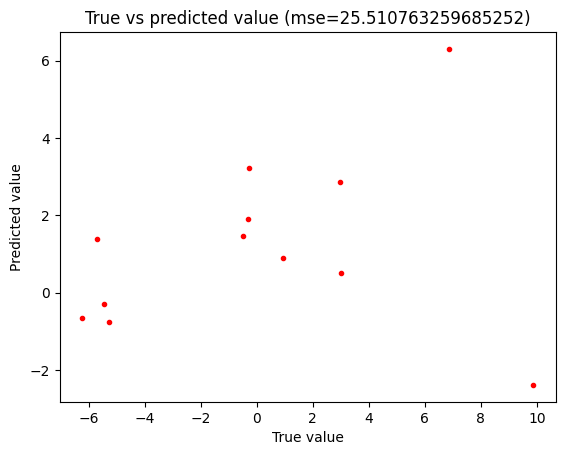

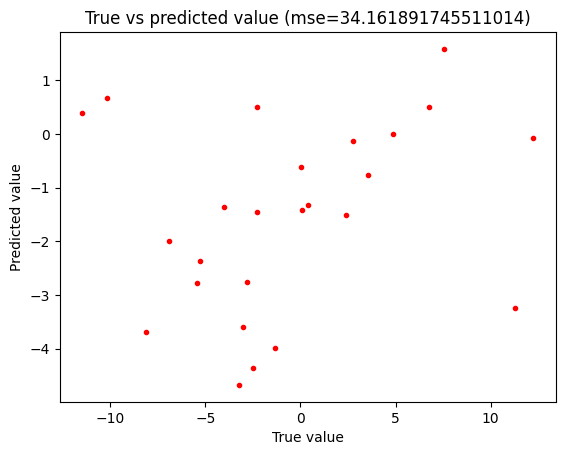

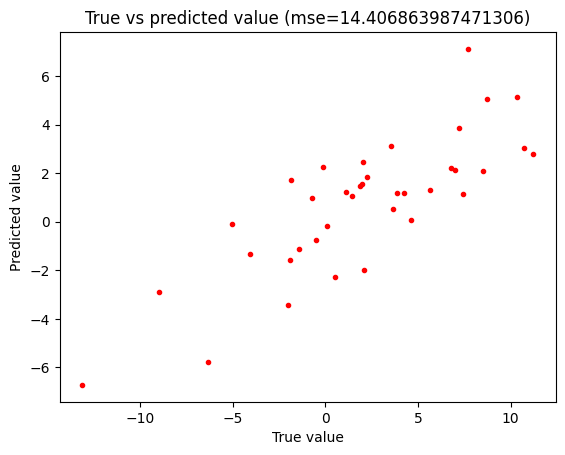

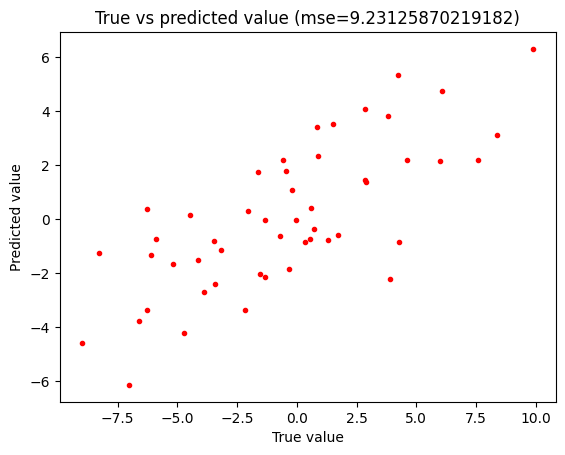

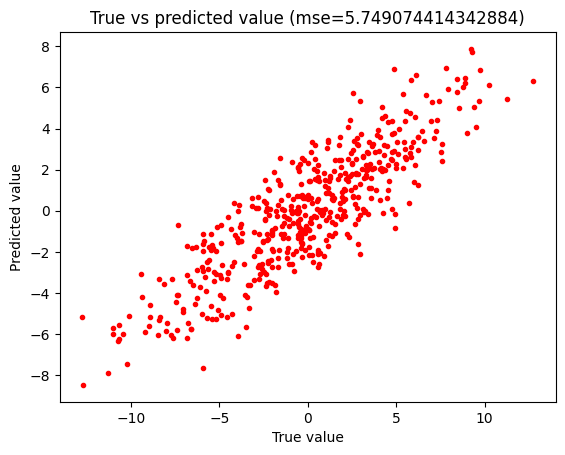

In [10]:
for i in range(len(n)):
    fig = plt.figure()
    plt.plot(y_test[i], y_pred_lasso[i], 'r.')
    plt.xlabel('True value')
    plt.ylabel('Predicted value')
    plt.title('True vs predicted value (mse='+str(mse_score_lasso[i])+')')
    plt.show()



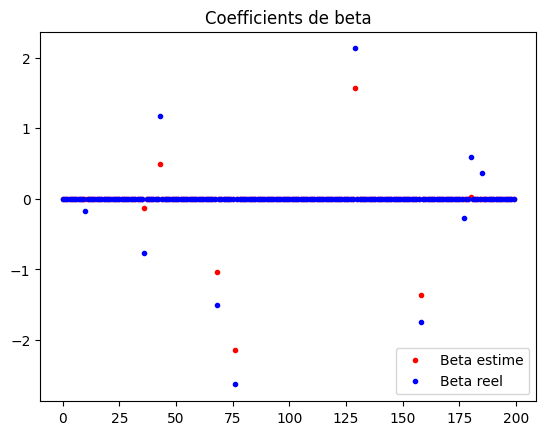

In [11]:

fig = plt.figure()
plt.plot(lasso_regressor.coef_, 'r.')
plt.plot(beta, 'b.')
plt.legend(('Beta estime', 'Beta reel'), loc='lower right')
plt.title('Coefficients de beta')
plt.show()



### <span style="color:blue">QUESTION 1</span> :

Jouez l'exemple avec  n=1000, n=100, n=75, n=50, n=25. Qu'en deduisez vous sur l'impact du nombre d'observations

### <span style="color:blue">REPONSE 1</span> :

le nombre d'observation a un fort impact sur la mse : visiblement plus il augmente, plus la mse est faible.



### <span style="color:blue">QUESTION 2</span> :

On garde n=75. Utilisez la validation croisee de type K-folds (typiquement 8-Folds) pour trouver le meilleur coefficient *alpha* au sens de la MSE. Pour chaque *alpha* testé, on gardera comme score la MSE moyenne obtenue sur tous les *folds*.

Remarque : la recherche d'un bon coefficient *alpha* pourra d'abord se faire sur une échelle exponentielle assez large (ex: 0.001, 0.01, 0.1, ...) puis être raffinée sur une échelle plus fine.  

### <span style="color:blue">REPONSE 2</span> :

In [ ]:

from sklearn.model_selection import KFold

#...





In [ ]:
#représentation des coefficients estimés (lasso_regressor.coef_) et de ceux
#avec lesquels les données ont été simulées (beta)

fig = plt.figure()
plt.plot(lasso_regressor.coef_, 'r.')
plt.plot(beta, 'b.')
plt.legend(('Beta estime', 'Beta reel'), loc='lower right')
plt.title('Coefficients de beta')
plt.show()


### <span style="color:blue">QUESTION 3</span> :

De manère alternative, codez et testez maintenant une sélection de type *forward* avec un critère de sélection *BIC*.

Comparez les résultats avec ceux obtenus à l'aide de la pénalisation LASSO.

### <span style="color:blue">REPONSE 3</span> :


In [ ]:


from sklearn.linear_model import LinearRegression

#...

